<a href="https://colab.research.google.com/github/Nilufar-Komil/Applications-of-the-Generalized-Stiefel-Manifold-in-NN/blob/main/CIFAR_10_%2Bcnn%2Badam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Beginning***

Problem is image classification. Number of classes are 10: cat, dog, bird and etc.Images' resolution are 32*32.
Do not forget to change the run time to the GPU.




#***Imports***
Lets start by getting all our imports, keep in mind that PyTorch is not automatically detects and trains on GPU, you have to tell it to use cuda. In case you want to train on Mac Silicon replace cuda with mps.

In [1]:
import torch.nn as nn
import random
import torch # Main PyTorch Library
import torchvision # Pytorch library for image analysis
from torchvision import transforms  # Transform function used to modify and preprocess all the images
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory
from torch.utils.data import random_split #Used to split data sets
device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cpu


#***Downoad Data Set***

In Colab, PyTorch can download it for me for CIFAR 10 data set.

In [2]:
import torchvision.transforms as transforms
transform = transforms.ToTensor()   # turn image into tensor

# Normalize all images: shift pixel values within -1 and 1
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=True,                     # use training data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",                  # save/load dataset in this folder
    train=False,                    # use test data
    download=True,                  # download if needed
    transform=transform             # apply transform
)

# print size of each data sets
print("Train size:", len(full_train_dataset))
print("Test size:", len(test_dataset))


100%|██████████| 170M/170M [00:02<00:00, 58.1MB/s]


Train size: 50000
Test size: 10000


#***Train / validation / test split***

In CIFAR 10 dataset training and test datasets are already separated. We split only training dataset to validation and training parts.




In [3]:
# split full training data set to training and validation parts
train_size = int(0.8 * len(full_train_dataset))   # 80% for training
val_size = len(full_train_dataset) - train_size   # 20% for validation

train_dataset, val_dataset = random_split(
    full_train_dataset,             # dataset to split
    [train_size, val_size],         # sizes of split parts
    generator=torch.Generator().manual_seed(42)   # makes the train/validation split stay the same every time
)

# printing each data sets sizes
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))



Train size: 40000
Val size: 10000
Test size: 10000



For standard CIFAR-10, we usually do not need a custom dataset class.
Because this already does the dataset job for us: `torchvision.datasets.CIFAR10(...)`

It already knows how to:
* load CIFAR-10
* return image and label
* apply transforms
* work with DataLoader

#***Define Hyperparameters***
We define hyperparameters: batch size, learning rate, and epoch.

In [4]:
# Defining hyperparameters
batch_size = 64
EPOCHS = 10

# Fixing randomness in each run: used in PyTorch, Numpy, Python, and GPU random operations:
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


#***DataLoaders***

PyTorch provides a class called DataLoader which allows us to create objects of it to simplify the training.

Dataloader is an object that we can loop through it to train according to batches. When we start training, we loop through epochs, if you skip the batch size it means that the amount of training data in one batch is equal to the complete amount of training data, this method is not efficient and in most of the cases you need to train through using batches. Dataloader allows you to loop through the batches easily during the training. When you create a dataloader. You define the batch size and enable the shuffle to randomize the data and then you can loop through it in each epoch to train normally.

In [5]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # shuffled train batches
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)      # validation batches
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)    # test batches


#***Visualizing random images from the datasets***

At this step, we want to inspect a few sample images from the training, validation, and test datasets. This is an important check before building and training the model. By looking at random images, we can confirm that the dataset was loaded correctly, the labels correspond to the right classes, and the preprocessing steps did not damage the images.

First, we extract the class names from the original CIFAR-10 dataset. These class names let us convert numeric labels such as 0, 1, or 2 into meaningful category names like airplane, automobile, or bird.

Then, we define a function that selects a few random images from a given dataset and displays them. Inside this function, we randomly choose image indices, retrieve the corresponding image-label pairs, and prepare the images for visualization. Since PyTorch stores images in the format [channels, height, width], we reorder the dimensions to [height, width, channels] so that matplotlib can display them correctly.

For each selected image, we show the image itself and write its class name as the title. We repeat this process for the training, validation, and test datasets so that we can visually compare samples from all three splits.

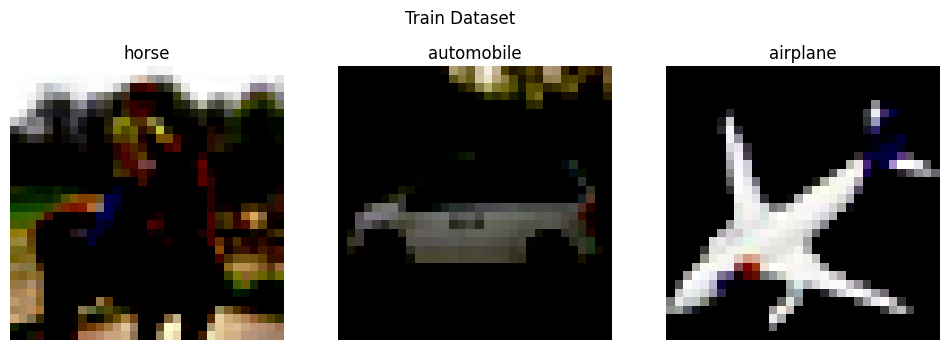

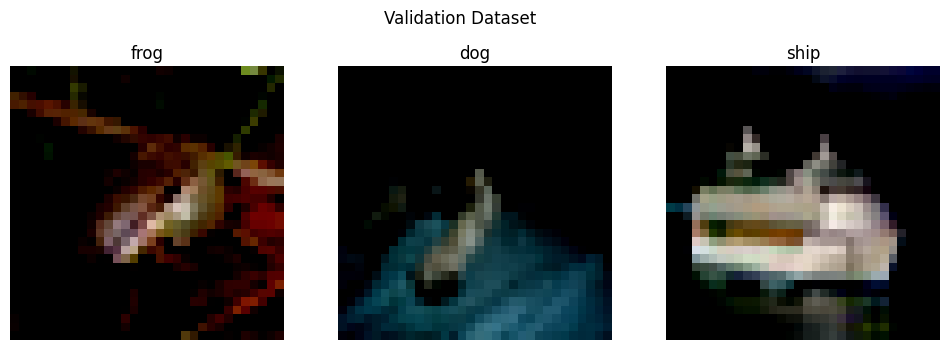

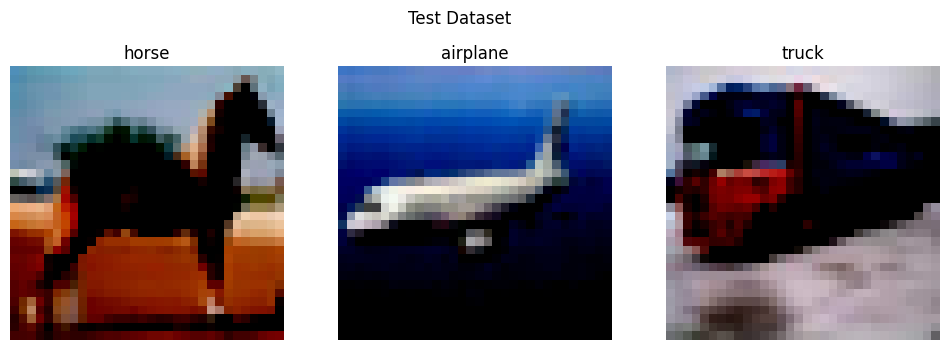

In [6]:
classes = full_train_dataset.classes   # CIFAR-10 class names: cat, dog and etc.

#define a function to show random images
def show_random_images(dataset, dataset_name, classes, num_images=3):
    plt.figure(figsize=(12, 4))   # create a figure

    random_indices = random.sample(range(len(dataset)), num_images)   # choose random indices

    for i, idx in enumerate(random_indices):
        image, label = dataset[idx]   # get image and label

        image = image.permute(1, 2, 0)   # change shape from [C, H, W] to [H, W, C]

        plt.subplot(1, num_images, i + 1)   # create subplot
        plt.imshow(image)   # show image
        plt.title(classes[label])   # show class name
        plt.axis("off")   # hide axes

    plt.suptitle(dataset_name)   # title for whole dataset row
    plt.show()

show_random_images(train_dataset, "Train Dataset", classes, num_images=3)
show_random_images(val_dataset, "Validation Dataset", classes, num_images=3)
show_random_images(test_dataset, "Test Dataset", classes, num_images=3)

#***Model***
Our model was built for CIFAR-10 input images:
* 3 channels = RGB
* 32 height
* 32 width

Our model consists of four convolutional layer and then flatten and fully connected NN. We use dropouts for avoiding overfitting.

In [7]:
class CIFAR10_CNN(nn.Module):
    def __init__(self): # output = floor((input + 2*padding - kernel_size) / stride) + 1
        super(CIFAR10_CNN, self).__init__()
        # input shape: 3*32*32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # output shape: 32*32*32
        self.relu1 = nn.ReLU() # output shape: 32*32*32
        self.pool1 = nn.MaxPool2d(2,2) # output shape: 32*16*16


        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # output shape: 64*16*16
        self.relu2 = nn.ReLU() # output shape: 64*16*16
        self.pool2 = nn.MaxPool2d(2, 2) # output shape: 64*8*8

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # output shape: 128*8*8
        self.relu3 = nn.ReLU() # output shape: 128*8*8
        self.pool3 = nn.MaxPool2d(2, 2) # output shape: 128*4*4

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1) # output shape: 256*4*4
        self.relu4 = nn.ReLU() # output shape: 256*4*4
        self.pool4 = nn.MaxPool2d(2, 2) # output shape: 256*2*2

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256*2*2, 256)
        self.relu5 = nn.ReLU()
        self.drop1 = nn.Dropout(0.2)   # dropout layer
        self.fc2 = nn.Linear(256, 128)
        self.relu6 = nn.ReLU()
        self.drop2 = nn.Dropout(0.5)   # dropout layer
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.pool4(self.relu4(self.conv4(x)))
        x = self.flatten(x)
        x = self.relu5(self.fc1(x))
        x = self.drop1(x)
        x = self.relu6(self.fc2(x))
        x = self.drop2(x)
        x = self.fc3(x)
        return x
model = CIFAR10_CNN().to(device)

#***Loss Function and Optimization Method***

As our probem is classification problem, we use Cross entropy as loss function and usual ADAM optimization method for backpropagation.
I would like to try three optimization methods:
* ADAM
* SGD
* LION.

In [8]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss() # Cross Entropy Loss

!pip install lion-pytorch
from lion_pytorch import Lion

def get_optimizer(name, model):
    if name == "adam":
        return torch.optim.Adam(model.parameters(), lr=1e-3)
    elif name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)
    elif name == "lion":
        return Lion(model.parameters(), lr=1e-4)
    else:
        raise ValueError("Unknown optimizer")

# Choose one optimizer to use by uncommenting the desired line below
# optimizer = get_optimizer("adam", model, LR)
# optimizer = get_optimizer("lion", model, LR)
optimizer = get_optimizer("sgd", model)


#***Training***
We store training and validation's loss and accuracy in per epoch. And visualize them as a plot graph.

In [9]:
import copy

def train_and_validate(model, train_loader, val_loader, train_dataset, val_dataset, optimizer, epochs, device):
    total_loss_train_plot = []
    total_loss_validation_plot = []
    total_acc_train_plot = []
    total_acc_validation_plot = []

    model.to(device)

    for epoch in range(epochs):
        model.train()

        total_acc_train = 0
        total_loss_train = 0

        total_loss_val = 0
        total_acc_val = 0

        # Training
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            train_loss = criterion(outputs, labels)
            total_loss_train += train_loss.item()

            train_loss.backward()
            optimizer.step()

            train_acc = (torch.argmax(outputs, dim=1) == labels).sum().item()
            total_acc_train += train_acc

        # Validation
        model.eval()
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                val_loss = criterion(outputs, labels)
                total_loss_val += val_loss.item()

                val_acc = (torch.argmax(outputs, dim=1) == labels).sum().item()
                total_acc_val += val_acc

        avg_train_loss = total_loss_train / len(train_loader)
        avg_val_loss = total_loss_val / len(val_loader)
        avg_train_acc = (total_acc_train / len(train_dataset)) * 100
        avg_val_acc = (total_acc_val / len(val_dataset)) * 100

        total_loss_train_plot.append(avg_train_loss)
        total_loss_validation_plot.append(avg_val_loss)
        total_acc_train_plot.append(avg_train_acc)
        total_acc_validation_plot.append(avg_val_acc)

        print(f"Epoch {epoch+1}/{epochs}, "
              f"Train Loss: {avg_train_loss:.4f}, "
              f"Train Accuracy: {avg_train_acc:.4f}%, "
              f"Validation Loss: {avg_val_loss:.4f}, "
              f"Validation Accuracy: {avg_val_acc:.4f}%")

    return {
        "train_loss": total_loss_train_plot,
        "val_loss": total_loss_validation_plot,
        "train_acc": total_acc_train_plot,
        "val_acc": total_acc_validation_plot
    }

In [10]:
initial_model_state = copy.deepcopy(model.state_dict())

In [11]:
results = {}
trained_models = {}

optimizers_config = {
    "Adam": lambda m: torch.optim.Adam(m.parameters(), lr=1e-3),
    "SGD": lambda m: torch.optim.SGD(m.parameters(), lr=1e-2, momentum=0.9),
    "RMSprop": lambda m: torch.optim.RMSprop(m.parameters(), lr=1e-3, momentum=0.9),
}

# Add Lion only if installed
from lion_pytorch import Lion
optimizers_config["Lion"] = lambda m: Lion(m.parameters(), lr=1e-4)

for opt_name, opt_fn in optimizers_config.items():
    print(f"\nTraining with {opt_name}\n" + "="*40)

    model_copy = CIFAR10_CNN().to(device)   # create fresh model
    model_copy.load_state_dict(initial_model_state)

    optimizer = opt_fn(model_copy)

    history = train_and_validate(
        model_copy,
        train_loader,
        val_loader,
        train_dataset,
        val_dataset,
        optimizer,
        EPOCHS,
        device
    )

    results[opt_name] = history
    trained_models[opt_name] = model_copy # Store the trained model


Training with Adam
Epoch 1/10, Train Loss: 1.6790, Train Accuracy: 36.5200%, Validation Loss: 1.2876, Validation Accuracy: 52.7000%
Epoch 2/10, Train Loss: 1.2272, Train Accuracy: 55.8200%, Validation Loss: 1.1005, Validation Accuracy: 59.7900%
Epoch 3/10, Train Loss: 1.0131, Train Accuracy: 64.1800%, Validation Loss: 0.9230, Validation Accuracy: 66.7900%
Epoch 4/10, Train Loss: 0.8566, Train Accuracy: 70.5225%, Validation Loss: 0.8562, Validation Accuracy: 70.4100%
Epoch 5/10, Train Loss: 0.7312, Train Accuracy: 75.2050%, Validation Loss: 0.7907, Validation Accuracy: 73.1500%
Epoch 6/10, Train Loss: 0.6282, Train Accuracy: 78.7900%, Validation Loss: 0.7984, Validation Accuracy: 72.3900%
Epoch 7/10, Train Loss: 0.5374, Train Accuracy: 81.7575%, Validation Loss: 0.8009, Validation Accuracy: 73.5200%
Epoch 8/10, Train Loss: 0.4530, Train Accuracy: 84.5950%, Validation Loss: 0.8595, Validation Accuracy: 73.8700%
Epoch 9/10, Train Loss: 0.3926, Train Accuracy: 86.6650%, Validation Loss: 0

#***Testing***
After training we test our model on test dataset.

In [12]:
test_results = {}

for opt_name, model in trained_models.items():
    model.eval()

    total_acc = 0
    total_loss = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            total_acc += (torch.argmax(outputs, dim=1) == labels).sum().item()

    acc = (total_acc / len(test_dataset)) * 100
    loss = total_loss / len(test_loader)

    test_results[opt_name] = (acc, loss)

    for opt_name, (acc, loss) in test_results.items():
      print(f"{opt_name}: Accuracy = {acc:.4f}%, Loss = {loss:.4f}")

Adam: Accuracy = 74.4800%, Loss = 0.9495
Adam: Accuracy = 74.4800%, Loss = 0.9495
SGD: Accuracy = 75.2800%, Loss = 0.7806
Adam: Accuracy = 74.4800%, Loss = 0.9495
SGD: Accuracy = 75.2800%, Loss = 0.7806
RMSprop: Accuracy = 30.8400%, Loss = 1.8084
Adam: Accuracy = 74.4800%, Loss = 0.9495
SGD: Accuracy = 75.2800%, Loss = 0.7806
RMSprop: Accuracy = 30.8400%, Loss = 1.8084
Lion: Accuracy = 74.7100%, Loss = 0.8347


#***Plotting results***
We plot loss and accuracy of training and validation data set. There will be two kind of problems: overfitting and underfitting.

## Overfitting and Underfitting

### Overfitting
Overfitting occurs when a model learns the training data too closely, including noise and unnecessary details. Because of this, it performs very well on training data but poorly on new, unseen data.

**Common signs:**
- High training accuracy
- Low validation or test accuracy

**How to reduce it:**
- Use more training data
- Reduce model complexity
- Apply regularization
- Use dropout
- Stop training early

---

### Underfitting
Underfitting occurs when a model is too simple to learn the underlying patterns in the data. As a result, it performs poorly on both training data and unseen data.

**Common signs:**
- Low training accuracy
- Low validation or test accuracy

**How to reduce it:**
- Use a more powerful model
- Train for more epochs
- Add better input features
- Reduce excessive regularization

---

### Summary
- **Overfitting:** good performance on training data, poor performance on new data  
- **Underfitting:** poor performance on both training data and new data

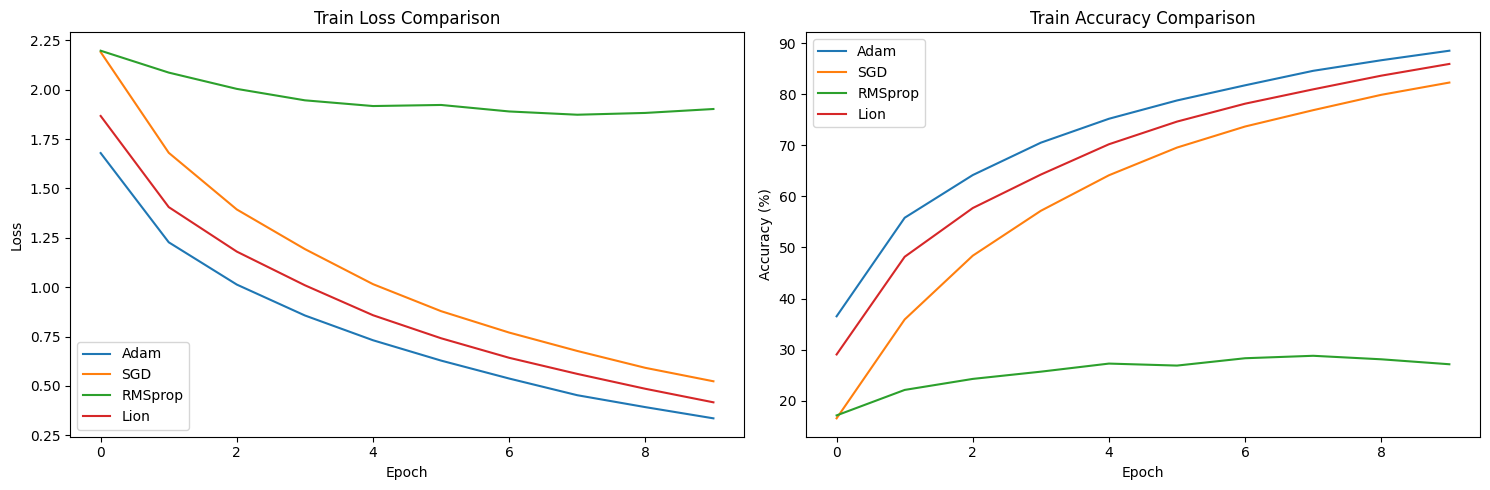

In [13]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

for opt_name, history in results.items():
    axs[0].plot(history["train_loss"], label=opt_name)
    axs[1].plot(history["train_acc"], label=opt_name)

axs[0].set_title("Train Loss Comparison")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].set_title("Train Accuracy Comparison")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy (%)")
axs[1].legend()

plt.tight_layout()
plt.show()

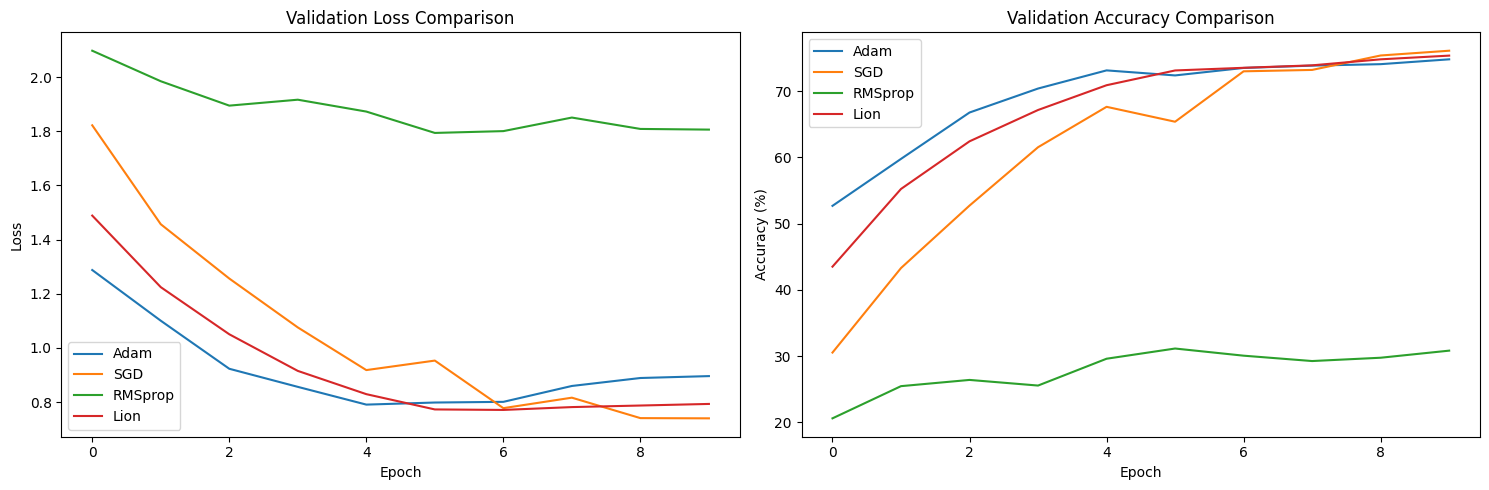

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

for opt_name, history in results.items():
    axs[0].plot(history["val_loss"], label=opt_name)
    axs[1].plot(history["val_acc"], label=opt_name)

axs[0].set_title("Validation Loss Comparison")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].set_title("Validation Accuracy Comparison")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy (%)")
axs[1].legend()

plt.tight_layout()
plt.show()

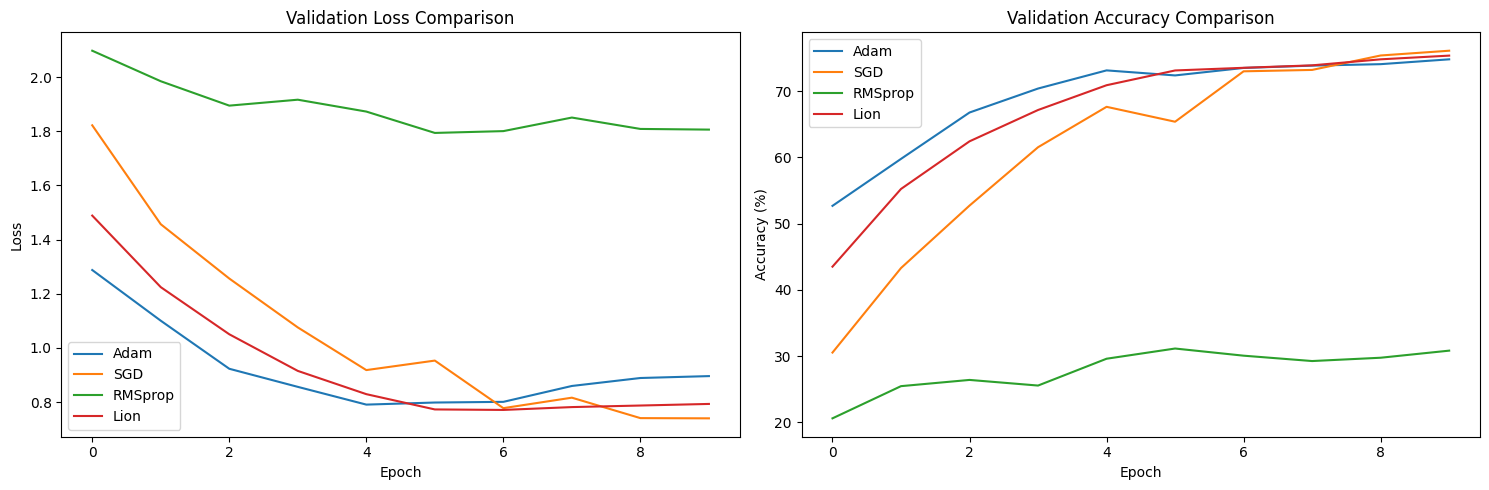

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

for opt_name, history in results.items():
    axs[0].plot(history["val_loss"], label=opt_name)
    axs[1].plot(history["val_acc"], label=opt_name)

axs[0].set_title("Validation Loss Comparison")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].set_title("Validation Accuracy Comparison")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy (%)")
axs[1].legend()

plt.tight_layout()
plt.show()